In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/Datasets/poly.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [62]:
df.drop('sno',axis=1,inplace=True)

In [63]:
df

,Temperature,Pressure
0,0,0.0002
1,20,0.0012
2,40,0.0060
3,60,0.0300
4,80,0.0900
5,100,0.2700


In [64]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [65]:
x

,Temperature
0,0
1,20
2,40
3,60
4,80
5,100


In [66]:
y

0    0.0002
1    0.0012
2    0.0060
3    0.0300
4    0.0900
5    0.2700
Name: Pressure, dtype: float64

In [67]:
df1=df['Pressure'].value_counts()
df1

Pressure
0.0002    1
0.0012    1
0.0060    1
0.0300    1
0.0900    1
0.2700    1
Name: count, dtype: int64

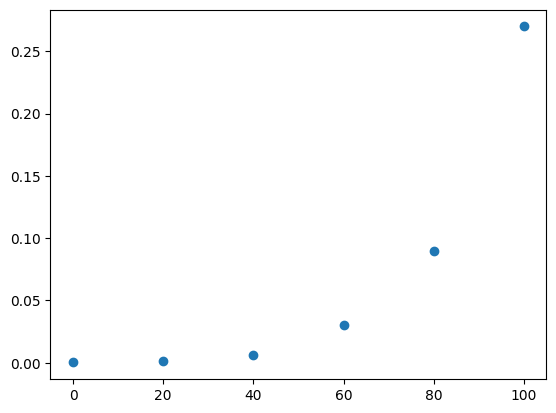

In [68]:
plt.scatter(x,y)

In [69]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
y_pred

array([-0.05086667, -0.00402667,  0.04281333,  0.08965333,  0.13649333,
        0.18333333])

In [70]:
df1=pd.DataFrame({'actual':y,'predicted':y_pred,'diff':y-y_pred})
df1

,actual,predicted,diff
0,0.0002,-0.050867,0.051067
1,0.0012,-0.004027,0.005227
2,0.0060,0.042813,-0.036813
3,0.0300,0.089653,-0.059653
4,0.0900,0.136493,-0.046493
5,0.2700,0.183333,0.086667


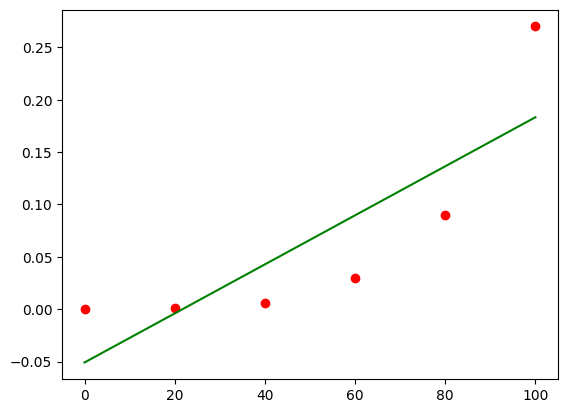

In [71]:
plt.scatter(x,y,color='r')
plt.plot(x,y_pred,color='g')

In [72]:
from sklearn.metrics import mean_absolute_percentage_error
MAPE=mean_absolute_percentage_error(y,y_pred)
MAPE

44.775078189300416

In [73]:
from sklearn.metrics import r2_score
score=r2_score(y,y_pred)*100
score

69.0349972603981

In [74]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x)
x_poly

array([[1.0e+00, 0.0e+00, 0.0e+00],
       [1.0e+00, 2.0e+01, 4.0e+02],
       [1.0e+00, 4.0e+01, 1.6e+03],
       [1.0e+00, 6.0e+01, 3.6e+03],
       [1.0e+00, 8.0e+01, 6.4e+03],
       [1.0e+00, 1.0e+02, 1.0e+04]])

In [75]:
model1=LinearRegression()
model1.fit(x_poly,y)
y_pred=model1.predict(x_poly)
y_pred

array([ 0.01555, -0.01731, -0.01032,  0.03652,  0.12321,  0.24975])

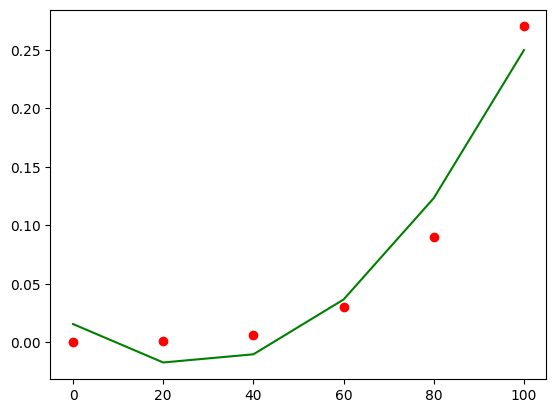

In [76]:
plt.scatter(x,y,color='r')
plt.plot(x,y_pred,color='g')

In [77]:
from sklearn.metrics import mean_absolute_percentage_error
MAPE=mean_absolute_percentage_error(y,y_pred)
MAPE

15.926055555558056

In [78]:
from sklearn.metrics import r2_score
score=r2_score(y,y_pred)*100
score

95.68461098911794